# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Text(0, 0.5, 'Second Principal Component Score')

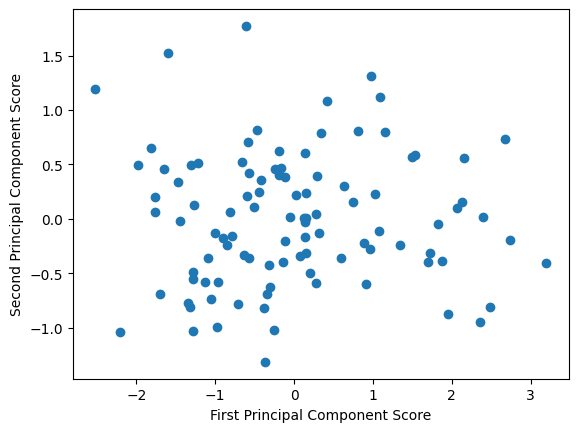

In [3]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt
import os
import kagglehub

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

- Advantages: The scatter plot of PC1 vs. PC2 scores visualizes data variance in reduced dimensions, highlighting outliers and clusters. It captures 98.9% of variance (0.799 + 0.190), showing major trends efficiently.
- Disadvantages: It loses detail about individual variables (e.g., series_1 vs. series_2) due to dimensionality reduction, and interpreting outliers requires understanding the PCA components, which can be complex.
- Insight: The plot reveals outliers with low series_3 values, suggesting potential anomalies in the data generation process (e.g., extreme noise in series_3).

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [4]:
data_path = kagglehub.dataset_download("khusheekapoor/vehicle-insurance-fraud-detection")
file = os.path.join(data_path, "carclaims.csv")
df = pd.read_csv(file)
print("Vehicle Insurance Fraud Detection Sample:")
print(df.head())

Vehicle Insurance Fraud Detection Sample:
  Month  WeekOfMonth  DayOfWeek    Make AccidentArea DayOfWeekClaimed  \
0   Dec            5  Wednesday   Honda        Urban          Tuesday   
1   Jan            3  Wednesday   Honda        Urban           Monday   
2   Oct            5     Friday   Honda        Urban         Thursday   
3   Jun            2   Saturday  Toyota        Rural           Friday   
4   Jan            5     Monday   Honda        Urban          Tuesday   

  MonthClaimed  WeekOfMonthClaimed     Sex MaritalStatus  ...  \
0          Jan                   1  Female        Single  ...   
1          Jan                   4    Male        Single  ...   
2          Nov                   2    Male       Married  ...   
3          Jul                   1    Male       Married  ...   
4          Feb                   2  Female        Single  ...   

   AgeOfPolicyHolder PoliceReportFiled WitnessPresent AgentType  \
0           26 to 30                No             No  Extern

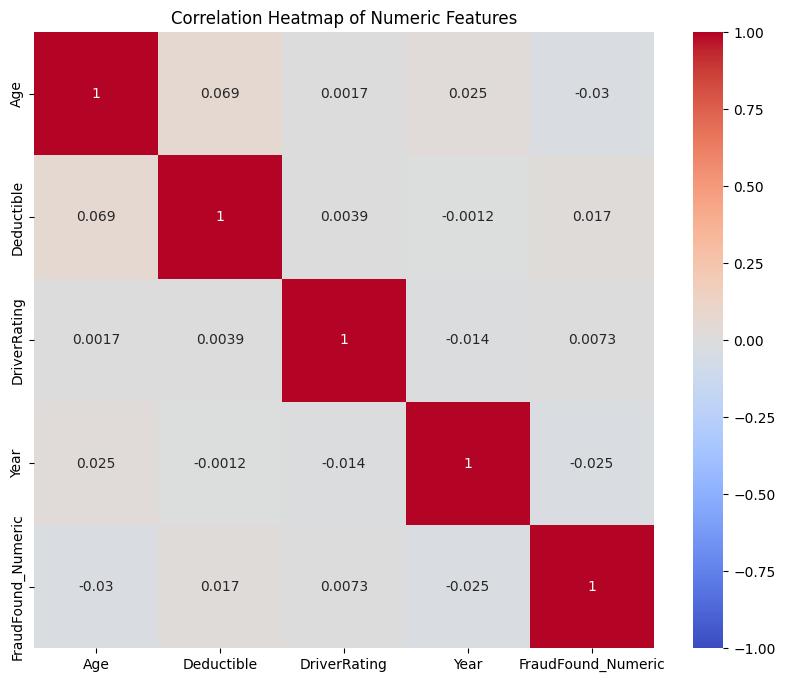

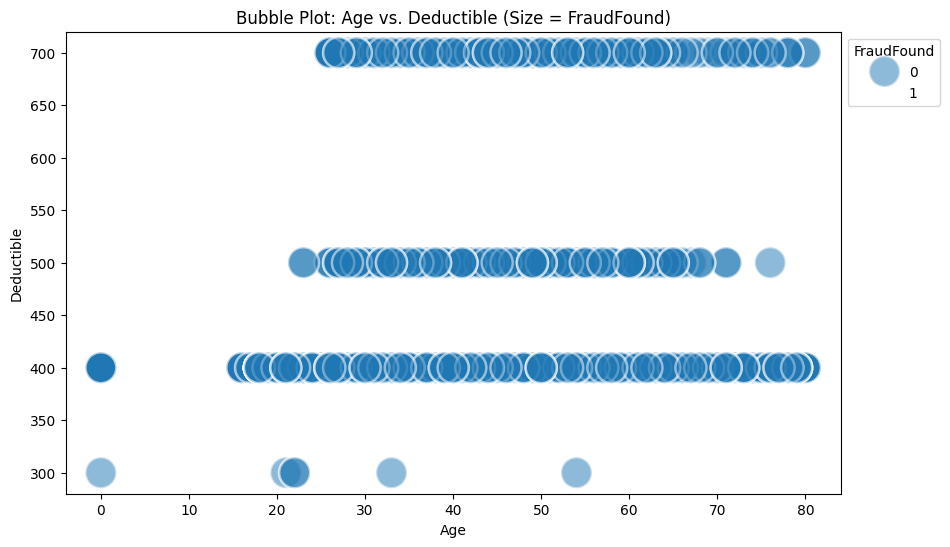

Explained Variance Ratio by Component:
[0.21547535 0.20726051 0.19923304 0.19481623 0.18321488]

Principal Component Vectors:
[[ 0.71318445  0.57822797 -0.03409795  0.30846126 -0.24639264]
 [ 0.06743544  0.47282913  0.37335064 -0.52106775  0.60081842]
 [ 0.06646738 -0.19679734  0.88226411 -0.02413473 -0.42175877]
 [-0.13007804 -0.01532055  0.28275009  0.78656601  0.5331147 ]
 [ 0.68226256 -0.63491819 -0.03330263 -0.11862325  0.34090491]]

Original Data (First 5 Rows):
   Age  Deductible  DriverRating  Year  FraudFound_Numeric
0   21         300             1  1994                   0
1   34         400             4  1994                   0
2   47         400             3  1994                   0
3   65         400             2  1994                   0
4   27         400             1  1994                   0

Reconstructed Data Using First Principal Component (First 5 Rows):
         Age  Deductible  DriverRating         Year  FraudFound_Numeric
0  14.462884  340.640428      2.5

In [5]:
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn import linear_model
from sklearn import metrics

df["FraudFound_Numeric"] = df["FraudFound"].map({"No": 0, "Yes": 1})

# Select numeric columns for multivariate analysis
numeric_cols = ["Age", "Deductible", "DriverRating", "Year", "FraudFound_Numeric"]
df_numeric = df[numeric_cols]

# 1. Heatmap of Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.savefig("correlation_heatmap_week9.png")
plt.show()

# 2. Bubble Plot
# Use Age vs. Deductible with FraudFound_Numeric as size
min_size = min(df_numeric['FraudFound_Numeric'])
max_size = max(df_numeric['FraudFound_Numeric'])
maxbubble = 500
minbubble = min_size / max_size * maxbubble if max_size != 0 else 1

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_numeric, x="Age", y="Deductible", size="FraudFound_Numeric", 
                sizes=(minbubble, maxbubble), alpha=0.5, hue="FraudFound_Numeric")
plt.title("Bubble Plot: Age vs. Deductible (Size = FraudFound)")
plt.xlabel("Age")
plt.ylabel("Deductible")
plt.legend(title="FraudFound", loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig("bubble_plot_week9.png")
plt.show()

# 3. Principal Component Analysis (PCA)
# Standardize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

# Perform PCA
pca = PCA(n_components=len(numeric_cols))
pca.fit(df_scaled)

# Print explained variance ratios and components
print("Explained Variance Ratio by Component:")
print(pca.explained_variance_ratio_)
print("\nPrincipal Component Vectors:")
print(pca.components_)

# Project data onto the first principal component
first_principal_component_score = df_scaled.dot(pca.components_[0])
# Reconstruct data using only the first principal component
df_reconstructed = np.outer(first_principal_component_score, pca.components_[0])
df_reconstructed = scaler.inverse_transform(df_reconstructed)
df_reconstructed = pd.DataFrame(df_reconstructed, columns=numeric_cols)

# Compare original and reconstructed data (first 5 rows)
print("\nOriginal Data (First 5 Rows):")
print(df_numeric.head())
print("\nReconstructed Data Using First Principal Component (First 5 Rows):")
print(df_reconstructed.head())

# 4. Linear Regression Using Correlation Insights
# From Week 6: Deductible vs. FraudFound_Numeric had the highest correlation (R = 0.1329)
# Predict FraudFound_Numeric using Age, Deductible, and DriverRating
linreg_fraud = linear_model.LinearRegression()
features = ['Age', 'Deductible', 'DriverRating']
linreg_fraud.fit(df_numeric[features], df_numeric['FraudFound_Numeric'])
preds_fraud = linreg_fraud.predict(df_numeric[features])
mse_fraud = metrics.mean_squared_error(preds_fraud, df_numeric['FraudFound_Numeric'])
corr_fraud = np.corrcoef(preds_fraud, df_numeric['FraudFound_Numeric'])[0, 1]
print("\nLinear Regression - Predicting FraudFound_Numeric:")
print(f"Features: {features}")
print(f"Mean Squared Error: {mse_fraud:.4f}")
print(f"Correlation Coefficient: {corr_fraud:.4f}")

# Predict Deductible using Age, DriverRating, and FraudFound_Numeric
linreg_deductible = linear_model.LinearRegression()
features_deductible = ['Age', 'DriverRating', 'FraudFound_Numeric']
linreg_deductible.fit(df_numeric[features_deductible], df_numeric['Deductible'])
preds_deductible = linreg_deductible.predict(df_numeric[features_deductible])
mse_deductible = metrics.mean_squared_error(preds_deductible, df_numeric['Deductible'])
corr_deductible = np.corrcoef(preds_deductible, df_numeric['Deductible'])[0, 1]
print("\nLinear Regression - Predicting Deductible:")
print(f"Features: {features_deductible}")
print(f"Mean Squared Error: {mse_deductible:.4f}")
print(f"Correlation Coefficient: {corr_deductible:.4f}")

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

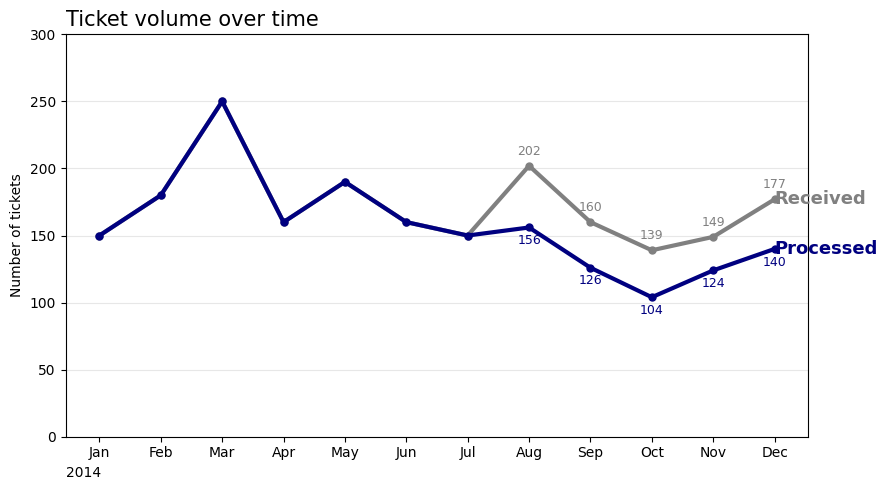

In [6]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
received = [150, 180, 250, 160, 190, 160, 150, 202, 160, 139, 149, 177]
processed = [150, 180, 250, 160, 190, 160, 150, 156, 126, 104, 124, 140]


plt.figure(figsize=(9, 5))
plt.plot(months, received, marker='o', color='grey', linewidth=3, markersize=5, label='Received')
plt.plot(months, processed, marker='o', color='navy', linewidth=3, markersize=5, label='Processed')


for i, txt in enumerate(received[7:]):
    plt.annotate(txt, (months[i+7], received[i+7]), textcoords="offset points", xytext=(0,8), ha='center', fontsize=9, color='grey')

for i, txt in enumerate(processed[7:]):
    plt.annotate(txt, (months[i+7], processed[i+7]), textcoords="offset points", xytext=(0,-12), ha='center', fontsize=9, color='navy')

plt.title('Ticket volume over time', fontsize=15, loc='left')
plt.ylabel('Number of tickets')
plt.xlabel('2014', loc='left')
plt.text('Dec', 177, 'Received', fontsize=13, color='grey', weight='bold', va='center', ha='left')
plt.text('Dec', 140, 'Processed', fontsize=13, color='navy', weight='bold', va='center', ha='left')

plt.grid(axis='y', linestyle='-', alpha=0.3)
plt.ylim(0, 300)
plt.tight_layout()
plt.legend().remove()
plt.show()
